# 03 - Trực quan Đồ thị

## Phát hiện Giao dịch Gian lận dựa trên Mạng Neural Đồ thị

Notebook này trực quan hóa cấu trúc đồ thị heterogeneous:
- Schema visualization (node types, edge types)
- Node statistics
- Edge statistics
- Subgraph sampling

In [1]:
import sys
sys.path.insert(0, '..')

from src.config import set_seed, DEVICE
from src.data_loader import IEEECISDataLoader
from src.graph_builder import HeteroGraphBuilder
from src.graph_visualizer import GraphVisualizer

set_seed(42)
print(f"Device: {DEVICE}")

c:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\Tuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_sparse\_version_cpu.pyd
  import torch_geometric.typing


Device: cpu


## 1. Load dữ liệu và xây dựng đồ thị

In [2]:
loader = IEEECISDataLoader()
df = loader.load()

builder = HeteroGraphBuilder(df)
data = builder.build()


LOADING DATA
Loaded 590,540 transactions
Fraud rate: 3.50% (20,663 fraud transactions)
txn_index range: 0 to 590539
Columns: ['txn_index', 'TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceInfo', 'DeviceType', 'id_30', 'id_31']
[load] completed in 1.06s

BUILDING HETEROGENEOUS GRAPH
Transaction nodes: 590,540
Building transaction features...
  Features shape: (590540, 6)
  Labels shape: (590540,) (fraud: 20,663)
[build_features] completed in 0.10s

BUILDING ENTITY INDEXERS
  card1: 8,419 unique values
  card2: 500 unique values
  card3: 90 unique values
  card4: 4 unique values
  card5: 91 unique values
  card6: 4 unique values
  addr1: 171 unique values
  addr2: 47 unique values
  p_email: 59 unique values
  r_email: 60 unique values
  device: 1,149 unique values
  devtype: 2 unique values
  os: 74 unique values
  browser: 111 unique values

Adding entity node

## 2. Trực quan hóa đồ thị

In [3]:
viz = GraphVisualizer(data)
viz.plot_all()

Generating Graph Visualizations
Plotting graph schema...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\graphs\graph_schema.png
Plotting node statistics...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\graphs\node_statistics.png
Plotting edge statistics...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\graphs\edge_statistics.png
Plotting subgraph (max 50 txn nodes)...
  Saved: D:\KLTN\Code\gian_lan_ieee\output\graphs\subgraph_sample.png

All graph visualizations saved to: D:\KLTN\Code\gian_lan_ieee\output\graphs


## 3. Hiển thị kết quả


--- edge_statistics ---


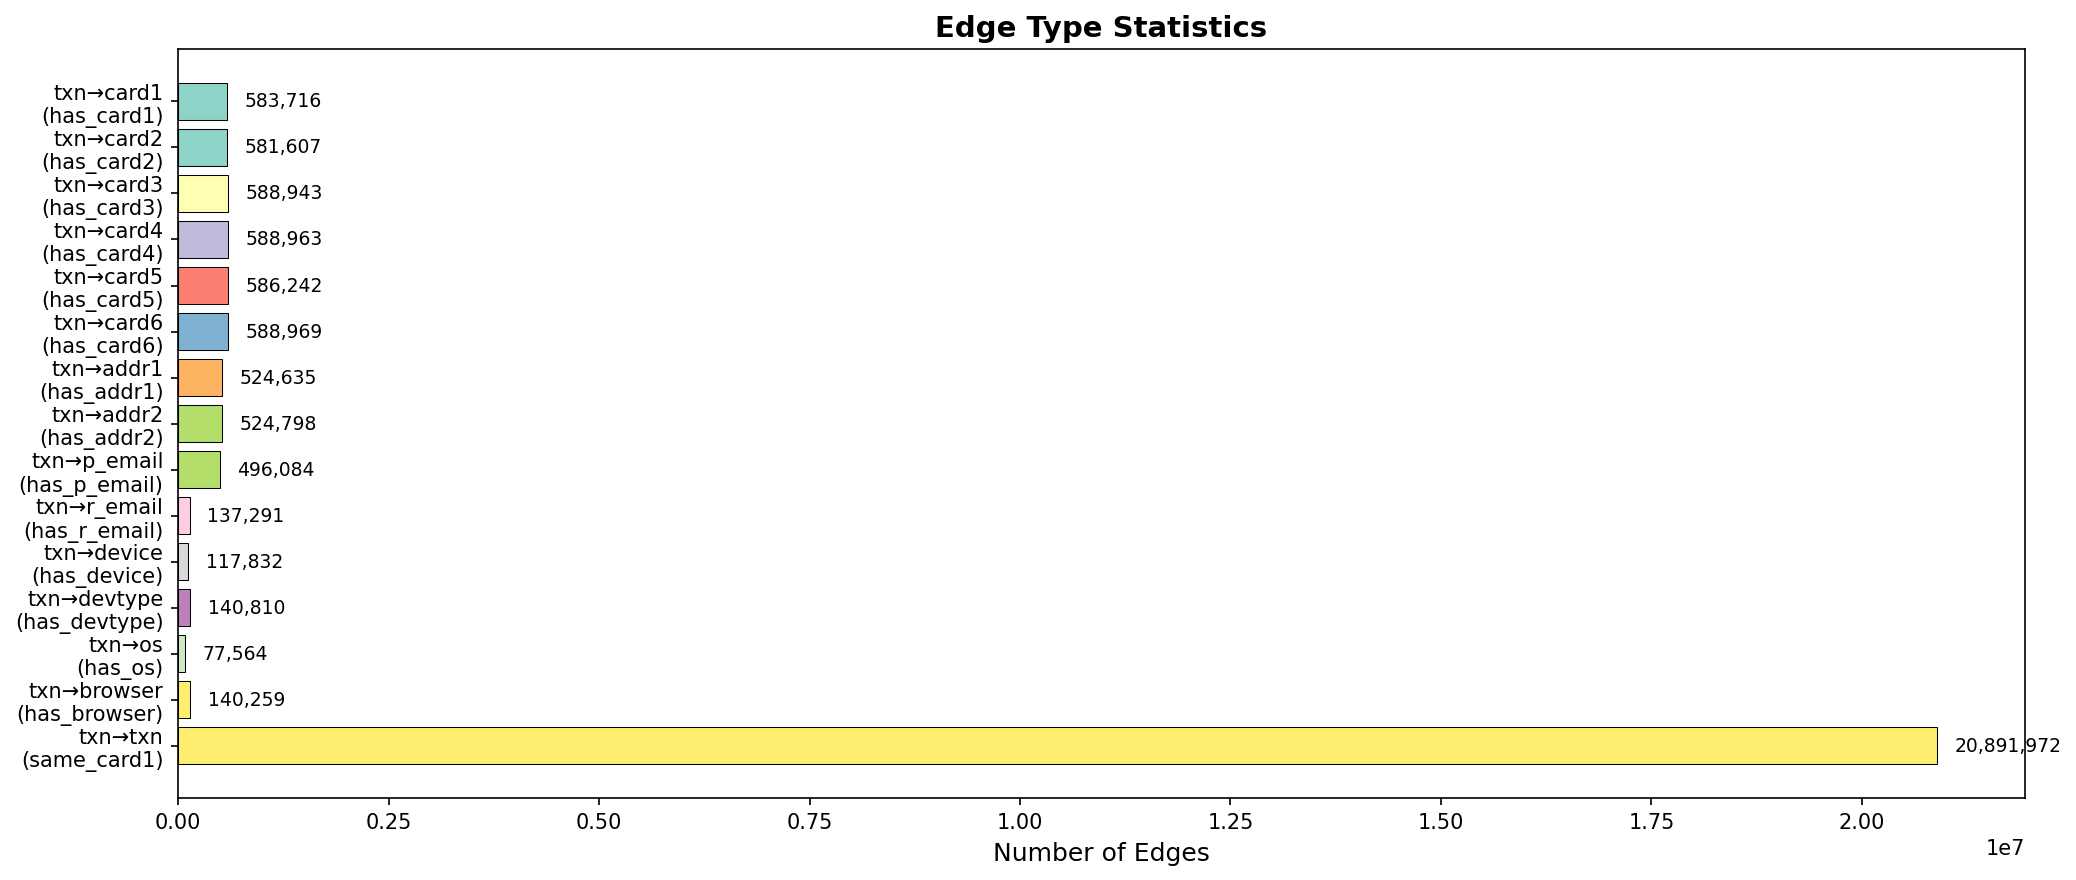


--- graph_schema ---


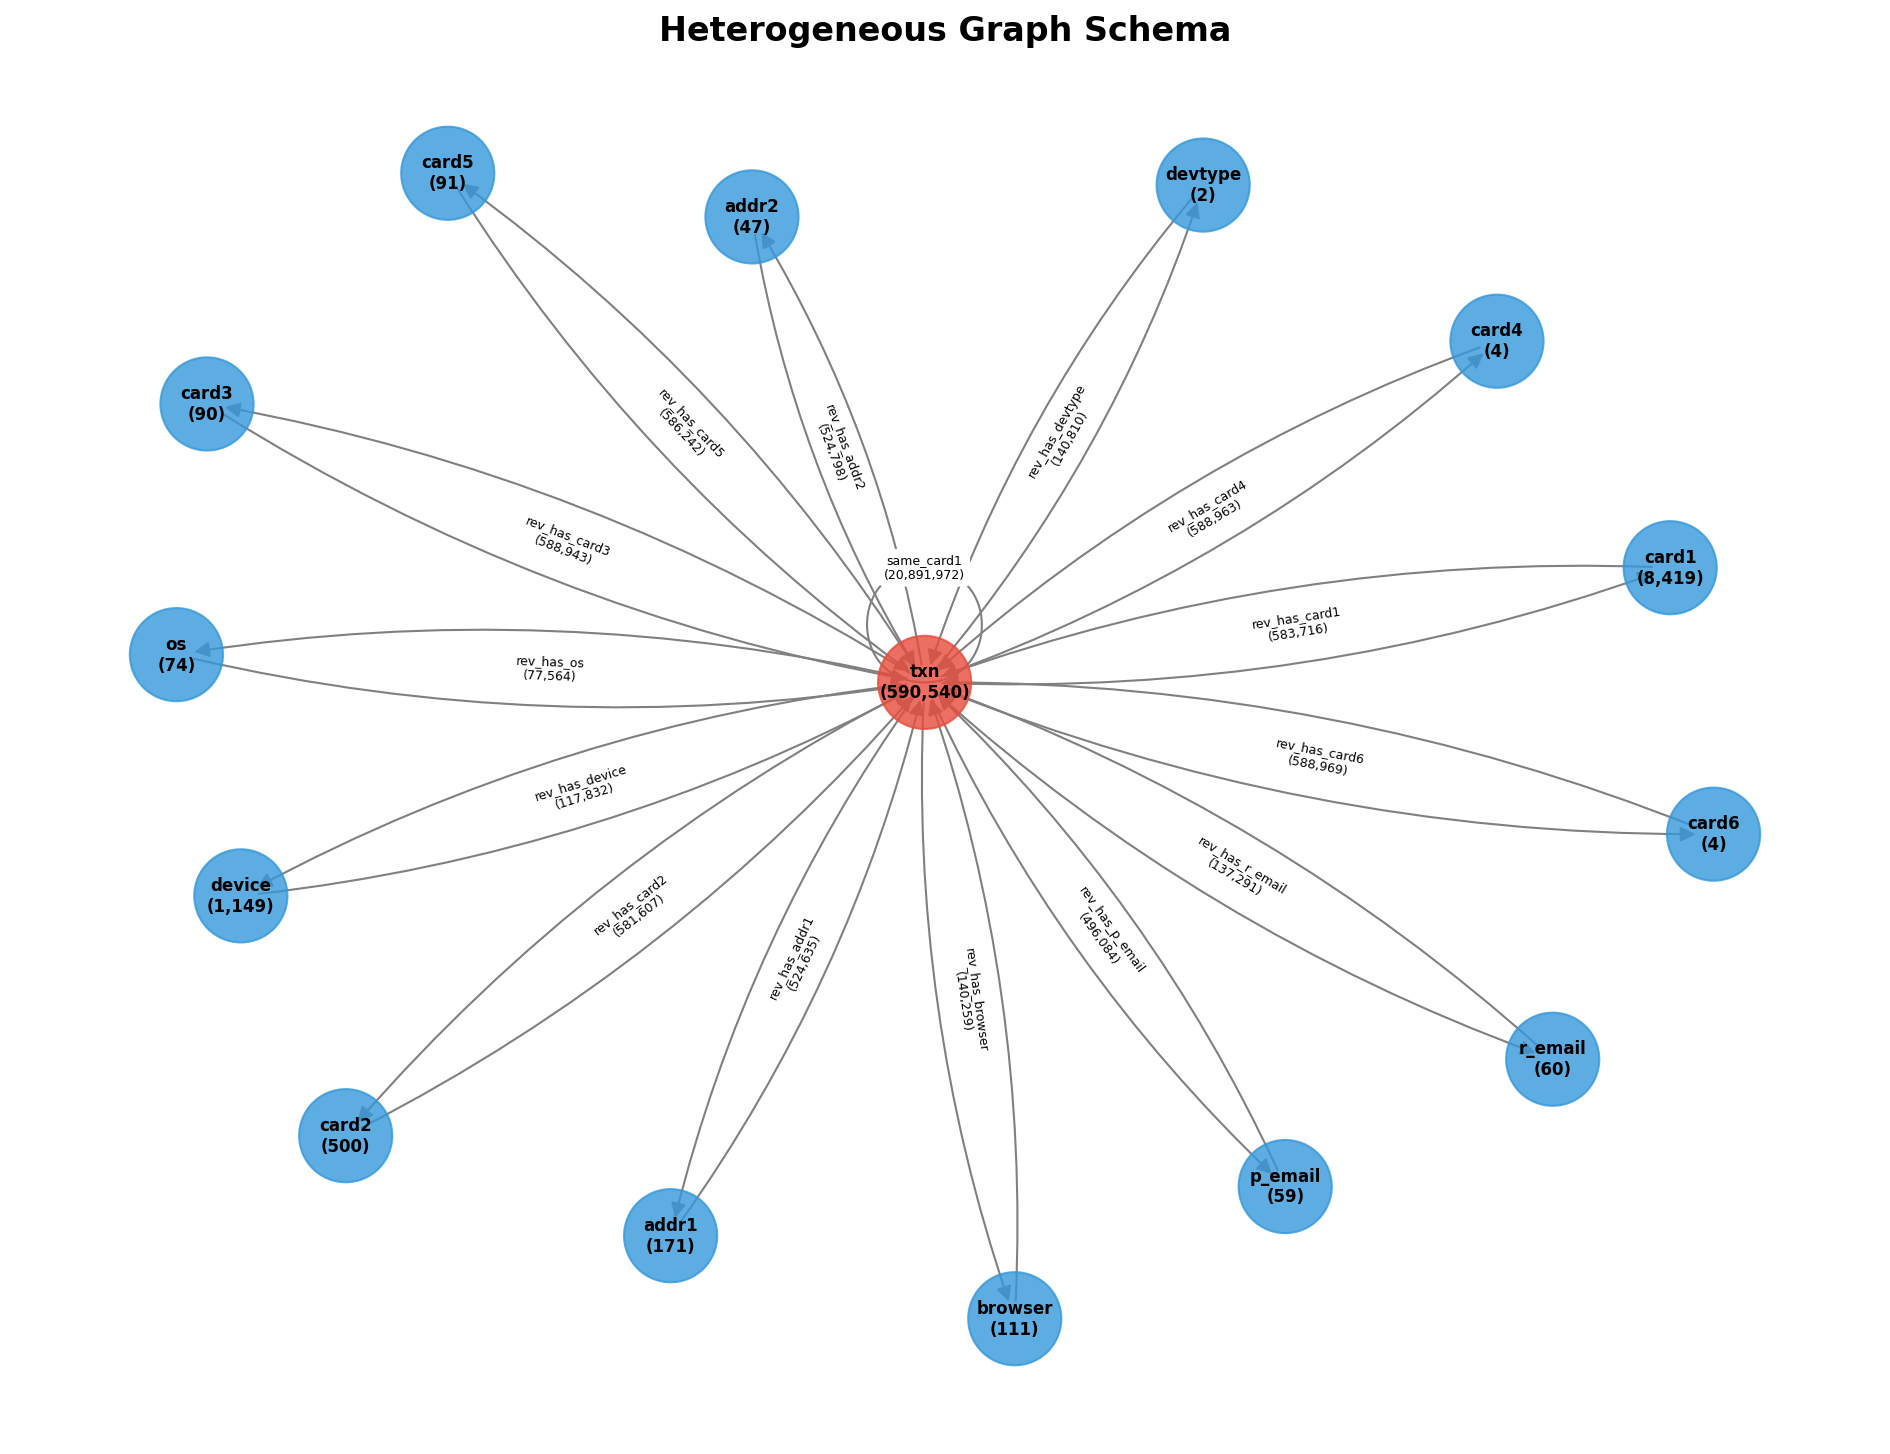


--- node_statistics ---


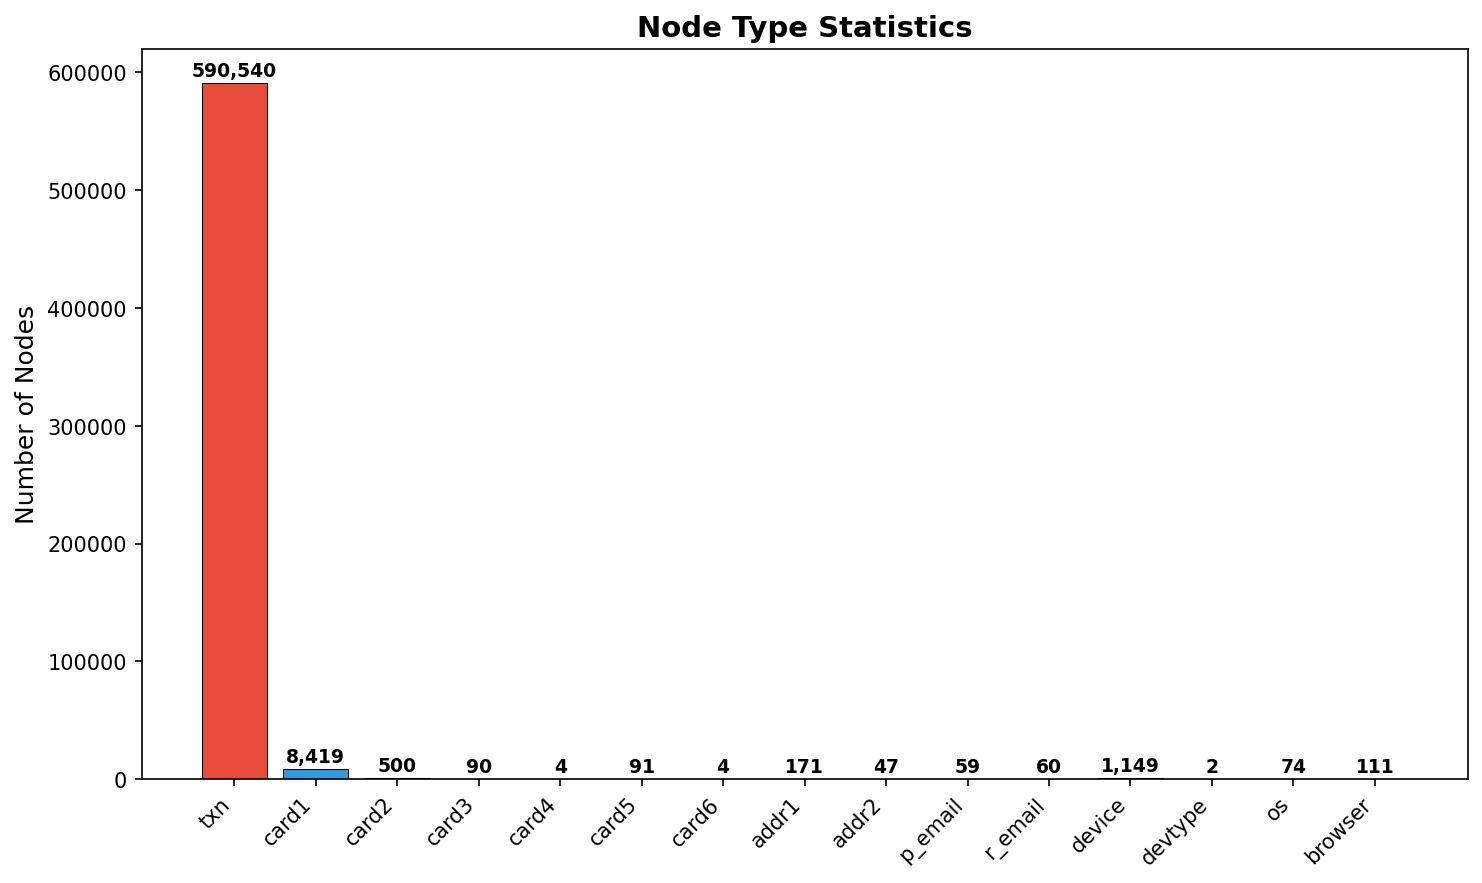


--- subgraph_sample ---


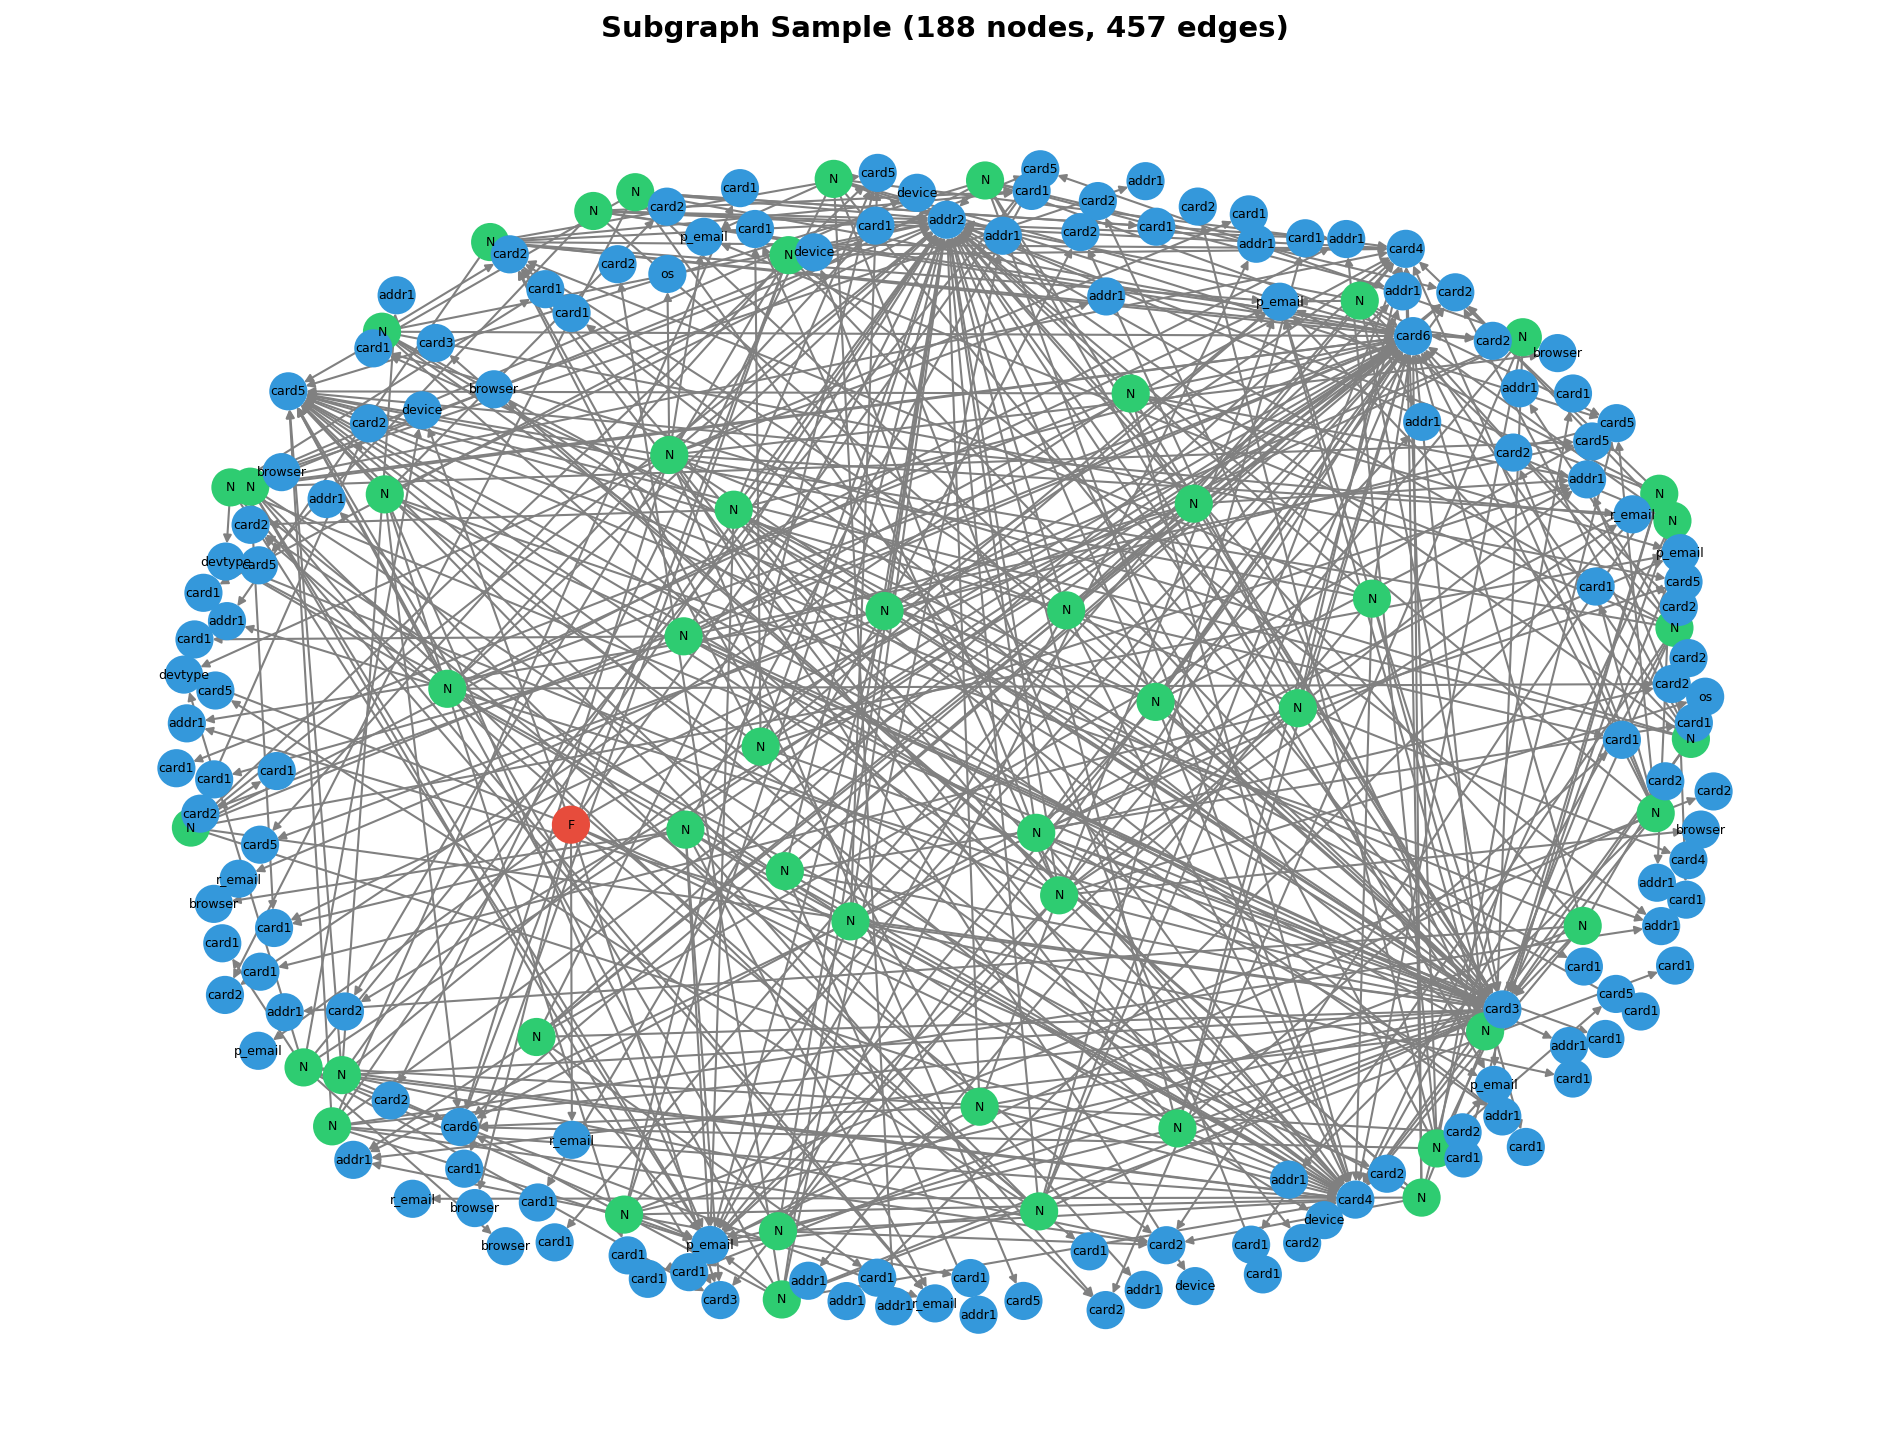

In [4]:
from IPython.display import Image, display
from pathlib import Path

graph_dir = Path('../output/graphs')
for img_path in sorted(graph_dir.glob('*.png')):
    print(f"\n--- {img_path.stem} ---")
    display(Image(filename=str(img_path), width=800))

## 4. Thống kê chi tiết

In [5]:
print("GRAPH STATISTICS")
print("=" * 60)

total_nodes = sum(data[nt].num_nodes for nt in data.node_types)
total_edges = sum(data[et].edge_index.shape[1] for et in data.edge_types)

print(f"Total node types: {len(data.node_types)}")
print(f"Total edge types: {len(data.edge_types)}")
print(f"Total nodes: {total_nodes:,}")
print(f"Total edges: {total_edges:,}")
print(f"\nAvg edges per node: {total_edges/total_nodes:.2f}")

# Fraud distribution in splits
for split in ['train', 'val', 'test']:
    mask = getattr(data['txn'], f'{split}_mask')
    y = data['txn'].y[mask]
    fraud_count = (y == 1).sum().item()
    total = mask.sum().item()
    print(f"\n{split.upper()}: {total:,} nodes, {fraud_count:,} fraud ({fraud_count/total*100:.2f}%)")

GRAPH STATISTICS
Total node types: 15
Total edge types: 29
Total nodes: 601,321
Total edges: 32,247,398

Avg edges per node: 53.63

TRAIN: 413,378 nodes, 14,538 fraud (3.52%)

VAL: 59,054 nodes, 2,061 fraud (3.49%)

TEST: 118,108 nodes, 4,064 fraud (3.44%)
